In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, LSTM, BatchNormalization, Dropout
from tensorflow.keras.models import Sequential


from tensorflow.keras.optimizers import AdamW
import pickle

2025-04-14 15:28:26.811363: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-14 15:28:26.844996: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-14 15:28:26.845179: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-14 15:28:26.846269: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-14 15:28:26.851914: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-14 15:28:26.852936: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [75]:
X = pd.read_csv('/work/preprocessed.csv')
y = pd.read_csv('/work/target.csv')['No Of Withdrawals']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train_norm = (y_train - y_train.min()) / (y_train.max() - y_train.min())
y_test_norm = (y_test - y_test.min()) / (y_test.max() - y_test.min())

# y_train_norm = y_train - y_train.mean() / y_train.std()
# y_test_norm = y_test - y_test.mean() / y_test.std()

In [77]:
def run_ann(X_train, y_train, validation_split=0.1):

    model = keras.Sequential([
        layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
        BatchNormalization(),
        layers.Dense(128, activation="relu"),
        Dropout(0.3),
        layers.Dense(32, activation="relu"),
        Dropout(0.3),
        BatchNormalization(),
        layers.Dense(1, activation="softplus"),
    ])

    optimizer = AdamW(learning_rate=1e-3)

    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    history = model.fit(X_train, y_train, epochs=200, validation_split=validation_split, batch_size = 32)
    

    return model, history


In [79]:
model_count, history_count = run_ann(X_train, y_train_norm, validation_split=0.1)

Epoch 1/200
286/286 [==============================] - 2s 3ms/step - loss: 0.2002 - mae: 0.3002 - val_loss: 0.0218 - val_mae: 0.1183
Epoch 2/200
286/286 [==============================] - 1s 2ms/step - loss: 0.0513 - mae: 0.1734 - val_loss: 0.0170 - val_mae: 0.1013
Epoch 3/200
286/286 [==============================] - 0s 2ms/step - loss: 0.0334 - mae: 0.1417 - val_loss: 0.0139 - val_mae: 0.0916
Epoch 4/200
286/286 [==============================] - 0s 2ms/step - loss: 0.0260 - mae: 0.1254 - val_loss: 0.0115 - val_mae: 0.0840
Epoch 5/200
286/286 [==============================] - 1s 2ms/step - loss: 0.0202 - mae: 0.1118 - val_loss: 0.0098 - val_mae: 0.0787
Epoch 6/200
286/286 [==============================] - 0s 2ms/step - loss: 0.0173 - mae: 0.1037 - val_loss: 0.0091 - val_mae: 0.0753
Epoch 7/200
286/286 [==============================] - 1s 2ms/step - loss: 0.0145 - mae: 0.0949 - val_loss: 0.0081 - val_mae: 0.0712
Epoch 8/200
286/286 [==============================] - 0s 1ms/step - 

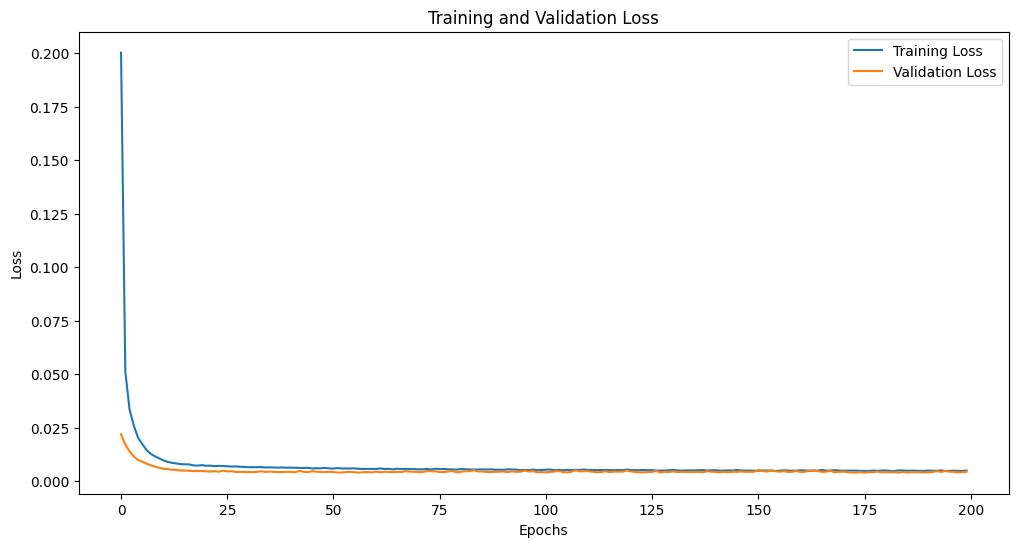

In [80]:
plt.figure(figsize=(12,6))
plt.plot(history_count.history['loss'], label='Training Loss')
plt.plot(history_count.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [81]:
model_count, history_count = run_ann(X_train, y_train_norm, validation_split=0.0)

Epoch 1/200
317/317 [==============================] - 1s 2ms/step - loss: 0.1485 - mae: 0.2624
Epoch 2/200
317/317 [==============================] - 0s 1ms/step - loss: 0.0352 - mae: 0.1457
Epoch 3/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0244 - mae: 0.1226
Epoch 4/200
317/317 [==============================] - 0s 2ms/step - loss: 0.0184 - mae: 0.1065
Epoch 5/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0147 - mae: 0.0951
Epoch 6/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0123 - mae: 0.0874
Epoch 7/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0105 - mae: 0.0804
Epoch 8/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0095 - mae: 0.0763
Epoch 9/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0088 - mae: 0.0730
Epoch 10/200
317/317 [==============================] - 0s 1ms/step - loss: 0.0083 - mae: 0.0704
Epoch 11/200
317/317 [=================

In [82]:

y_pred_counts = model_count.predict(X_test).flatten()
y_pred_counts = (y_pred_counts * (y_test.max() - y_test.min()) + y_test.min()).astype('int')
# y_pred_counts = (y_pred_counts * y_test.std() + y_test.mean()).astype('int')

80/80 [==============================] - 0s 756us/step


In [83]:
def calculate_smape(actual, predicted):

    if len(actual.shape) > 0:
      actual = np.array(actual).flatten()

    if len(predicted.shape) > 0:
      predicted = np.array(predicted).flatten()

    absolute_diff = np.abs(actual - predicted)
    sum_absolute = np.abs(actual) + np.abs(predicted)

    # Avoid division by zero
    mask = sum_absolute != 0
    smape = np.mean(200 * (absolute_diff[mask] / sum_absolute[mask]))

    return smape


def get_results(y_test, y_pred, name=''):

    score = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    smape = calculate_smape(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    results = pd.DataFrame({
        'Name': [name], 'R2 Score': [score],
        'MAE': [mae],   'MSE': [mse],
        'MAPE': [mape],  'SMAPE': [smape]
    })

    return results


In [84]:
get_results(y_test, y_pred_counts, name='ANN')

,Name,R2 Score,MAE,MSE,MAPE,SMAPE
0,ANN,0.840412,14.848126,498.745562,0.22262,16.352733


In [85]:
new_y = model_count.predict(X).flatten()
new_y = (new_y * (y.max() - y.min()) + y.min()).astype('int')
new_y

397/397 [==============================] - 0s 831us/step


array([ 71,  29,  80, ..., 150, 125,  63])

In [86]:
get_results(y, new_y, name='ANN')

,Name,R2 Score,MAE,MSE,MAPE,SMAPE
0,ANN,0.890286,12.164181,328.938619,0.194801,14.051595


In [87]:
new_X = X.copy()
new_X['No Of Withdrawals'] = StandardScaler().fit_transform(new_y.reshape(-1, 1)).flatten() 
new_X

,num__No Of XYZ Card Withdrawals,num__Amount withdrawn XYZ Card,nom__ATM Name_Big Street ATM,nom__ATM Name_Christ College ATM,nom__ATM Name_KK Nagar ATM,nom__ATM Name_Mount Road ATM,nom__Month_August,nom__Month_December,nom__Month_February,nom__Month_January,...,nom__Weekday_Monday,nom__Weekday_Saturday,nom__Weekday_Sunday,nom__Weekday_Thursday,nom__Weekday_Tuesday,nom__Weekday_Wednesday,ord__Festival Religion,ord__Working Day,ord__Holiday Sequence,No Of Withdrawals
0,-0.149954,0.234995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,-0.799547
1,-1.066562,-1.373230,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,5.0,-1.560303
2,-0.939255,-0.813505,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,-0.636528
3,2.472564,1.206763,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,9.470668
4,0.130121,-0.168638,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,3.402728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12670,0.257428,0.464141,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,5.0,2.0,8.0,-0.201810
12671,-0.455490,0.007952,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,5.0,2.0,8.0,0.359701
12672,-0.175415,-0.025159,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,5.0,2.0,8.0,0.631400
12673,0.435657,1.783832,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,5.0,2.0,8.0,0.178569


In [88]:
new_y = pd.read_csv('/work/target.csv')['Total amount Withdrawn']

new_X_train, new_X_test, new_y_train, new_y_test = train_test_split(new_X, new_y, test_size=0.2, random_state=42)

new_y_train_norm = (new_y_train - new_y_train.min()) / (new_y_train.max() - new_y_train.min())
new_y_test_norm = (new_y_test - new_y_test.min()) / (new_y_test.max() - new_y_test.min())

model_amt, history_amt = run_ann(new_X_train, new_y_train_norm, validation_split=0.1)


Epoch 1/200
286/286 [==============================] - 1s 2ms/step - loss: 0.1784 - mae: 0.2830 - val_loss: 0.0147 - val_mae: 0.0944
Epoch 2/200
286/286 [==============================] - 0s 2ms/step - loss: 0.0444 - mae: 0.1553 - val_loss: 0.0092 - val_mae: 0.0731
Epoch 3/200
286/286 [==============================] - 0s 2ms/step - loss: 0.0259 - mae: 0.1204 - val_loss: 0.0070 - val_mae: 0.0646
Epoch 4/200
286/286 [==============================] - 0s 2ms/step - loss: 0.0189 - mae: 0.1044 - val_loss: 0.0053 - val_mae: 0.0564
Epoch 5/200
286/286 [==============================] - 0s 2ms/step - loss: 0.0144 - mae: 0.0919 - val_loss: 0.0048 - val_mae: 0.0544
Epoch 6/200
286/286 [==============================] - 0s 2ms/step - loss: 0.0117 - mae: 0.0834 - val_loss: 0.0041 - val_mae: 0.0504
Epoch 7/200
286/286 [==============================] - 0s 2ms/step - loss: 0.0099 - mae: 0.0779 - val_loss: 0.0037 - val_mae: 0.0482
Epoch 8/200
286/286 [==============================] - 0s 2ms/step - 

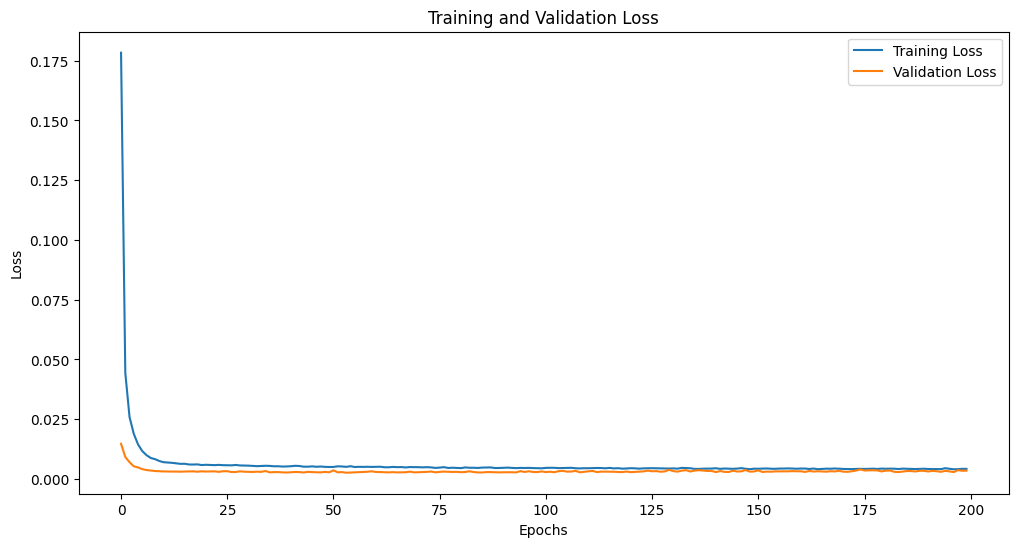

In [89]:
plt.figure(figsize=(12,6))
plt.plot(history_amt.history['loss'], label='Training Loss')
plt.plot(history_amt.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()


In [90]:
model_amt, history_amt = run_ann(new_X_train, new_y_train_norm, validation_split=0.0)

Epoch 1/200
317/317 [==============================] - 1s 1ms/step - loss: 0.1274 - mae: 0.2488
Epoch 2/200
317/317 [==============================] - 0s 1ms/step - loss: 0.0285 - mae: 0.1269
Epoch 3/200
317/317 [==============================] - 0s 1ms/step - loss: 0.0173 - mae: 0.1011
Epoch 4/200
317/317 [==============================] - 0s 1ms/step - loss: 0.0124 - mae: 0.0866
Epoch 5/200
317/317 [==============================] - 0s 1ms/step - loss: 0.0100 - mae: 0.0777
Epoch 6/200
317/317 [==============================] - 0s 1ms/step - loss: 0.0089 - mae: 0.0737
Epoch 7/200
317/317 [==============================] - 0s 1ms/step - loss: 0.0076 - mae: 0.0680
Epoch 8/200
317/317 [==============================] - 0s 1ms/step - loss: 0.0071 - mae: 0.0660
Epoch 9/200
317/317 [==============================] - 0s 1ms/step - loss: 0.0066 - mae: 0.0635
Epoch 10/200
317/317 [==============================] - 0s 1ms/step - loss: 0.0066 - mae: 0.0637
Epoch 11/200
317/317 [=================

In [91]:
y_pred_amount = model_amt.predict(new_X_test).flatten()
y_pred_amount = (y_pred_amount * (new_y_test.max() - new_y_test.min()) + new_y_test.min()).astype('int')
# y_pred_amount = (y_pred_amount * new_y_test.std() + new_y_test.mean()).astype('int')

get_results(new_y_test, y_pred_amount, name='ANN')

80/80 [==============================] - 0s 941us/step


,Name,R2 Score,MAE,MSE,MAPE,SMAPE
0,ANN,0.897837,57910.319921,6.219655e+09,0.597756,16.675082


In [92]:
pd.DataFrame(y_pred_counts, columns=['No Of Withdrawals']).to_csv('y_pred_counts.csv', index=False)
pd.DataFrame(y_pred_amount, columns=['Total amount Withdrawn']).to_csv('y_pred_amount.csv', index=False)

In [107]:
new_y = model_count.predict(X).flatten()
new_y = (new_y * (y.max() - y.min()) + y.min()).astype('int')

pd.DataFrame(new_y, columns=['No Of Withdrawals']).to_csv('counts_pred.csv', index=False)

397/397 [==============================] - 0s 1ms/step


In [109]:
with open('model_count.pkl', 'wb') as f:
    pickle.dump(model_count, f)

with open('model_amt.pkl', 'wb') as f:
    pickle.dump(model_amt, f)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=6c5dcd7e-ee44-459a-9dd6-5c39b2404cb3' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>